# ============================================================
# Notebook 05 — Temporal Fusion Transformer (TFT)
# FI-2010 Level-2 Order Book Classification
# ============================================================

In [ ]:

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully.")

All libraries imported successfully.


# ============================================================
# 2. Reproducibility and Device Configuration
# ============================================================

In [3]:

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Random seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Random seed: 42
Device: cpu


# ============================================================
# 3. Load Processed FI-2010 Dataset
# ============================================================

In [4]:

DATA_DIR = "../datasets/processed/FI2010"

X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_val   = np.load(os.path.join(DATA_DIR, "X_val.npy"))
X_test  = np.load(os.path.join(DATA_DIR, "X_test.npy"))

y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(DATA_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print("FI-2010 data loaded successfully!")
print()
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)
print()
print("y_train shape:", y_train.shape)
print("y_val shape:  ", y_val.shape)
print("y_test shape: ", y_test.shape)

FI-2010 data loaded successfully!

X_train shape: (25450, 100, 143)
X_val shape:   (6289, 100, 143)
X_test shape:  (362301, 100, 143)

y_train shape: (25450,)
y_val shape:   (6289,)
y_test shape:  (362301,)


# ============================================================
# 4. Verify Target Labels
# ============================================================

In [5]:
print("Unique labels in training set:", np.unique(y_train))
print("Unique labels in validation set:", np.unique(y_val))
print("Unique labels in test set:", np.unique(y_test))
print("\nTraining label counts:")
print(pd.Series(y_train).value_counts().sort_index())

Unique labels in training set: [0 1 2]
Unique labels in validation set: [0 1 2]
Unique labels in test set: [0 1 2]

Training label counts:
0    10267
1     6011
2     9172
Name: count, dtype: int64


# ============================================================
# 5. Dataset Information
# ============================================================

In [ ]:
SEQUENCE_LENGTH = X_train.shape[1]
INPUT_SIZE = X_train.shape[2]
NUM_CLASSES = len(np.unique(y_train))

print("Sequence length:", SEQUENCE_LENGTH)
print("Number of input features:", INPUT_SIZE)
print("Number of classes:", NUM_CLASSES)

Sequence length: 100
Number of input features: 143
Number of classes: 3


# ============================================================
# 6. Class Distribution
# ============================================================

In [7]:


class_names = {
    0: "Down",
    1: "Stable",
    2: "Up"
}

labels, counts = np.unique(y_train, return_counts=True)

print("Training class distribution:")

for label, count in zip(labels, counts):
    print(f"{label} ({class_names[label]}): {count}")

Training class distribution:
0 (Down): 10267
1 (Stable): 6011
2 (Up): 9172


# ============================================================
# 7. Visualize Class Distribution
# ============================================================


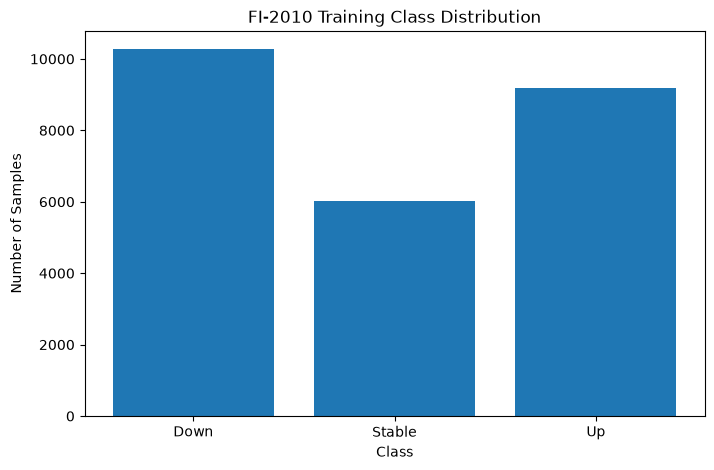

In [8]:

plt.figure(figsize=(8, 5))

plt.bar(
    [class_names[label] for label in labels],
    counts
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("FI-2010 Training Class Distribution")
plt.show()

# ============================================================
# 8. PyTorch Dataset
# ============================================================

In [ ]:
class LOBDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = LOBDataset(X_train, y_train)
val_dataset = LOBDataset(X_val, y_val)
test_dataset = LOBDataset(X_test, y_test)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 25450
Validation samples: 6289
Test samples: 362301


# ============================================================
# 9. Verify Dataset Sample
# ============================================================

In [10]:
sample_X, sample_y = train_dataset[0]

print("Sample X shape:", sample_X.shape)
print("Sample label:", sample_y.item())
print("Sample X dtype:", sample_X.dtype)
print("Sample y dtype:", sample_y.dtype)

Sample X shape: torch.Size([100, 143])
Sample label: 0
Sample X dtype: torch.float32
Sample y dtype: torch.int64


# ============================================================
# 10. DataLoaders
# ============================================================

In [11]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Batch size:", BATCH_SIZE)
print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

Batch size: 64
Number of training batches: 398
Number of validation batches: 99
Number of test batches: 5661


# ============================================================
# 11. DataLoader Sanity Check
# ============================================================


In [12]:

X_batch, y_batch = next(iter(train_loader))

print("Batch X shape:", X_batch.shape)
print("Batch y shape:", y_batch.shape)
print("Batch X dtype:", X_batch.dtype)
print("Batch y dtype:", y_batch.dtype)

Batch X shape: torch.Size([64, 100, 143])
Batch y shape: torch.Size([64])
Batch X dtype: torch.float32
Batch y dtype: torch.int64
